# 🌾 India Crop Yield Prediction — Notebook 6: Final Evaluation & Interpretability

**Goal:** Comprehensively evaluate the final tuned model on the test set, analyze errors, and interpret predictions using SHAP.

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('SHAP not installed. Run: pip install shap')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 2. Load Final Model & Test Data

In [2]:
model = joblib.load('models/final_tuned_model.pkl')

X_test = pd.read_csv('processed/X_test_raw.csv')
y_test = pd.read_csv('processed/y_test.csv').squeeze()
X_train = pd.read_csv('processed/X_train_raw.csv')
y_train = pd.read_csv('processed/y_train.csv').squeeze()

with open('processed/feature_cols.json') as f:
    feature_cols = json.load(f)

with open('models/tuning_summary.json') as f:
    summary = json.load(f)

print(f'Model loaded: {summary["best_model_name"]}')
print(f'Test set: {X_test.shape}')

Model loaded: XGB (Tuned)
Test set: (2604, 16)


## 3. Final Test-Set Metrics

In [3]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

metrics_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'MAPE (%)'],
    'Value':  [r2, rmse, mae, mape]
})

print('=== FINAL TEST SET METRICS ===')
print(metrics_df.to_string(index=False))

metrics_df.to_csv('models/final_test_metrics.csv', index=False)

=== FINAL TEST SET METRICS ===
  Metric        Value
      R² 9.663275e-01
    RMSE 2.475393e-01
     MAE 1.285323e-01
MAPE (%) 3.715774e+14


## 4. Actual vs Predicted

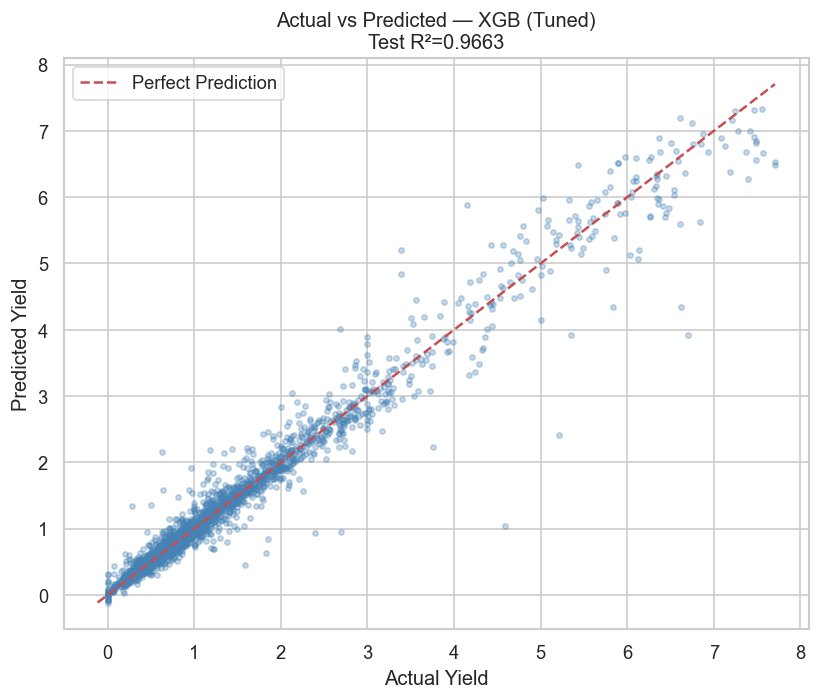

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Yield')
ax.set_ylabel('Predicted Yield')
ax.set_title(f'Actual vs Predicted — {summary["best_model_name"]}\nTest R²={r2:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('final_actual_vs_predicted.png')
plt.show()

## 5. Residual Analysis

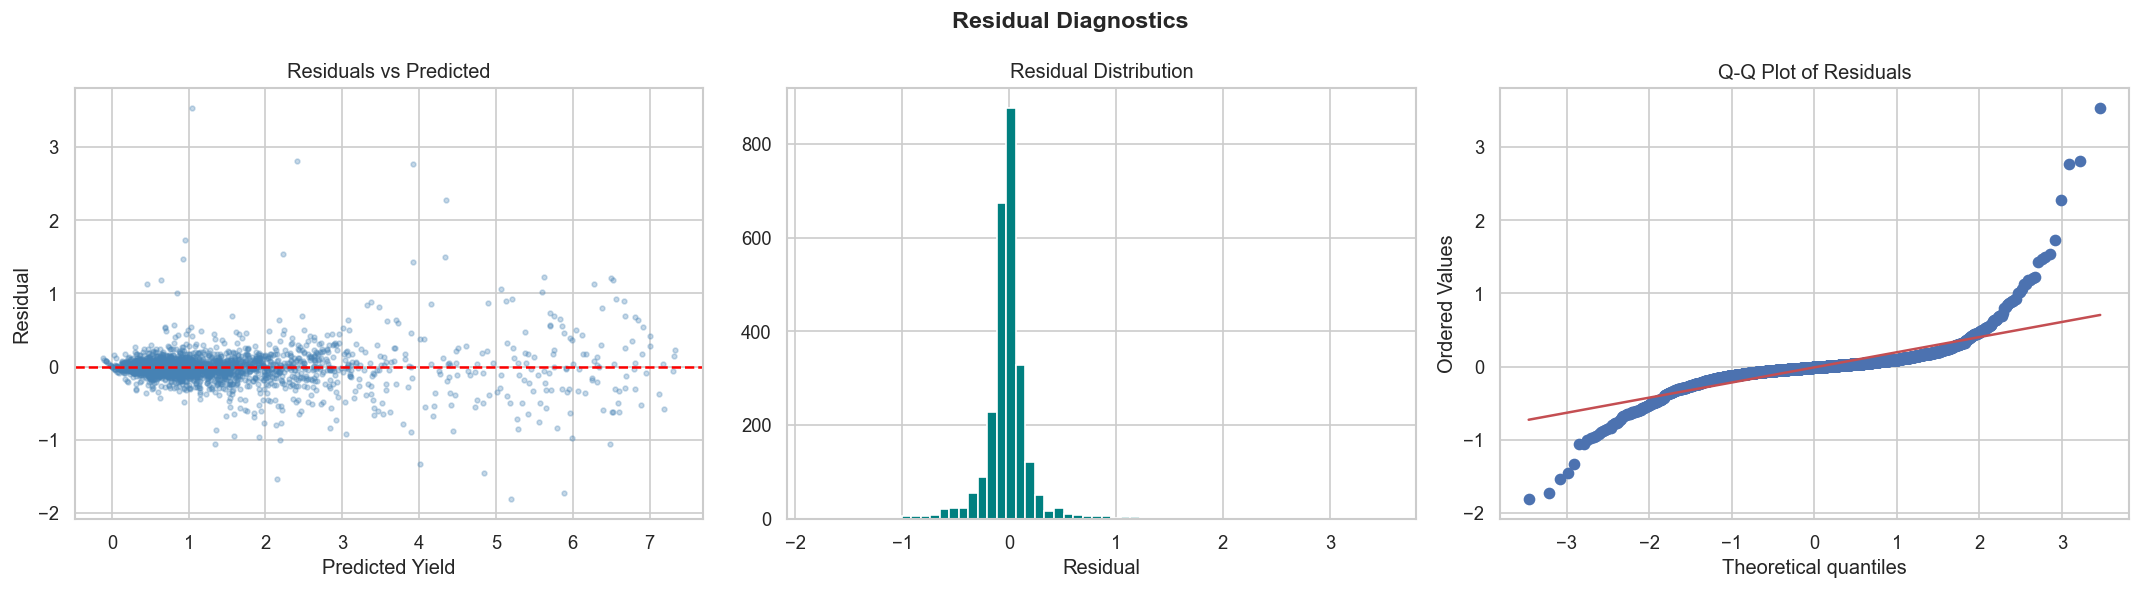

In [5]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.3, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Yield')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# Residual distribution
axes[1].hist(residuals, bins=60, color='teal', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

# Q-Q Plot
from scipy import stats
stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

plt.suptitle('Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_residual_analysis.png')
plt.show()

## 6. Error Analysis by Crop and State

In [6]:
# Load full processed data to get original labels
df_full = pd.read_csv('processed/crop_processed.csv')
le_dict = joblib.load('label_encoders.pkl')

test_idx = X_test.index
error_df = df_full.loc[test_idx, ['Crop', 'State', 'Season', 'Yield']].copy()
error_df['Predicted'] = y_pred
error_df['AbsError']  = np.abs(error_df['Yield'] - error_df['Predicted'])
error_df['PctError']  = error_df['AbsError'] / (error_df['Yield'].abs() + 1e-6) * 100

print('Mean Absolute Error by Season:')
print(error_df.groupby('Season')['AbsError'].mean().sort_values(ascending=False))

Mean Absolute Error by Season:
Season
Whole Year    1.825190
Summer        1.355961
Kharif        1.226216
Autumn        1.224664
Winter        1.200152
Rabi          1.054563
Name: AbsError, dtype: float64


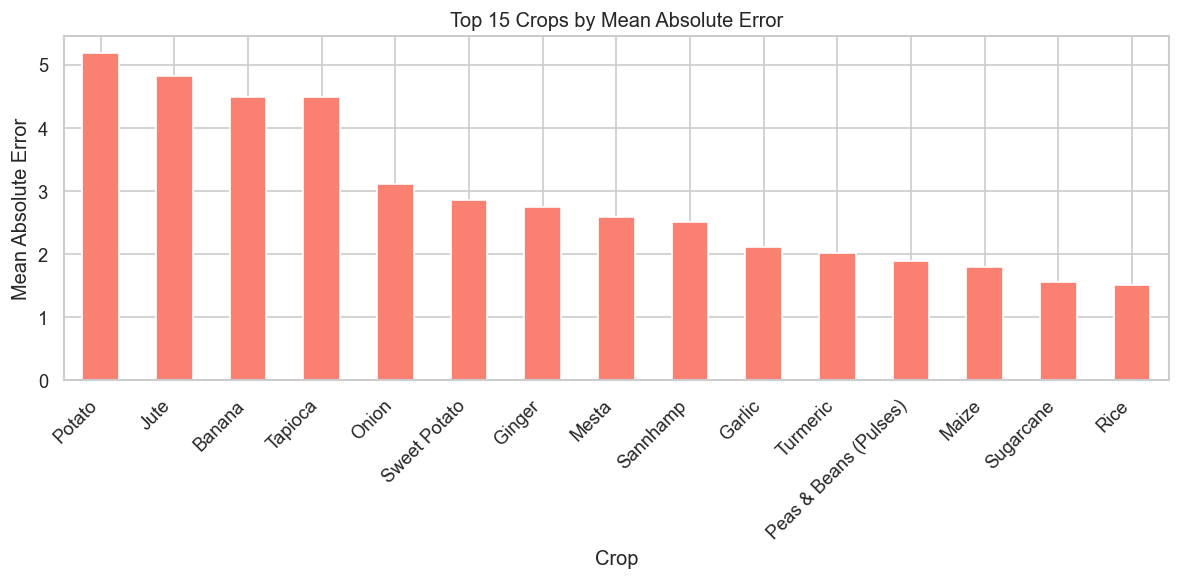

In [7]:
# Top 15 crops by error
crop_error = error_df.groupby('Crop')['AbsError'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
crop_error.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Top 15 Crops by Mean Absolute Error')
ax.set_xlabel('Crop')
ax.set_ylabel('Mean Absolute Error')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('error_by_crop.png')
plt.show()

## 7. SHAP Explanations 

In [12]:
import shap, xgboost
print(shap.__version__)
print(xgboost.__version__)

0.49.1
3.2.0


Computing SHAP values (may take a few minutes)...


PermutationExplainer explainer: 501it [07:43,  1.08it/s]                                                               


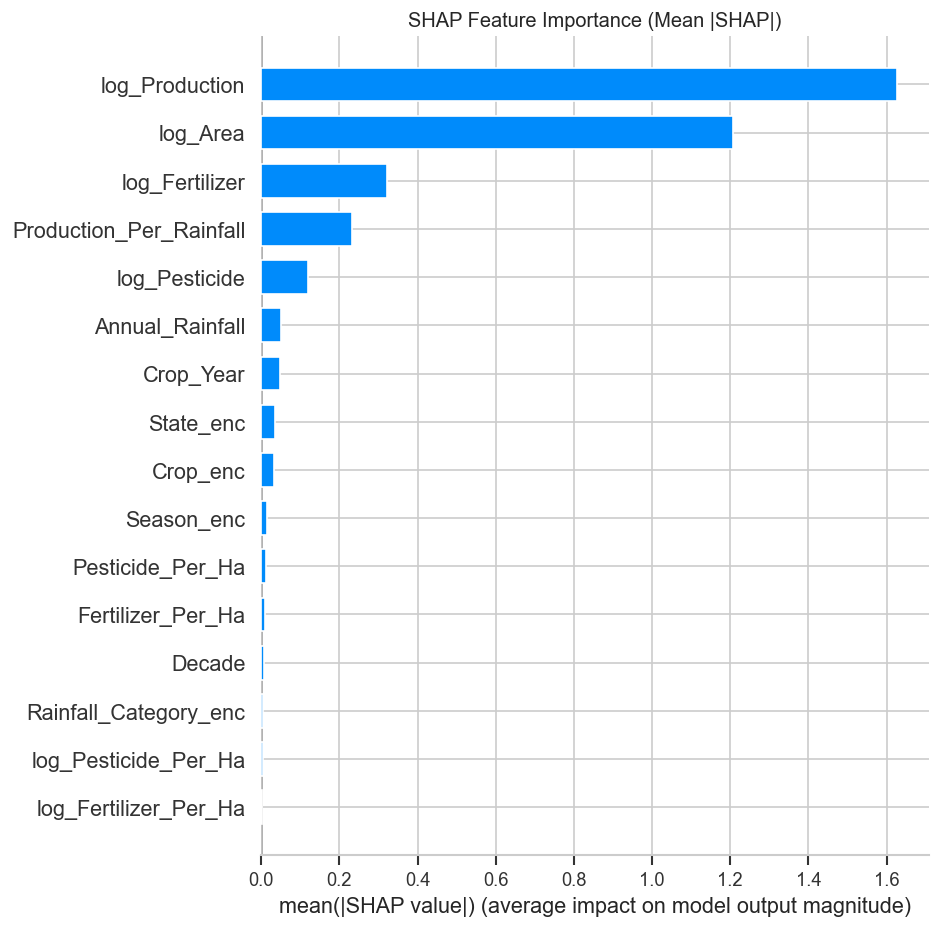

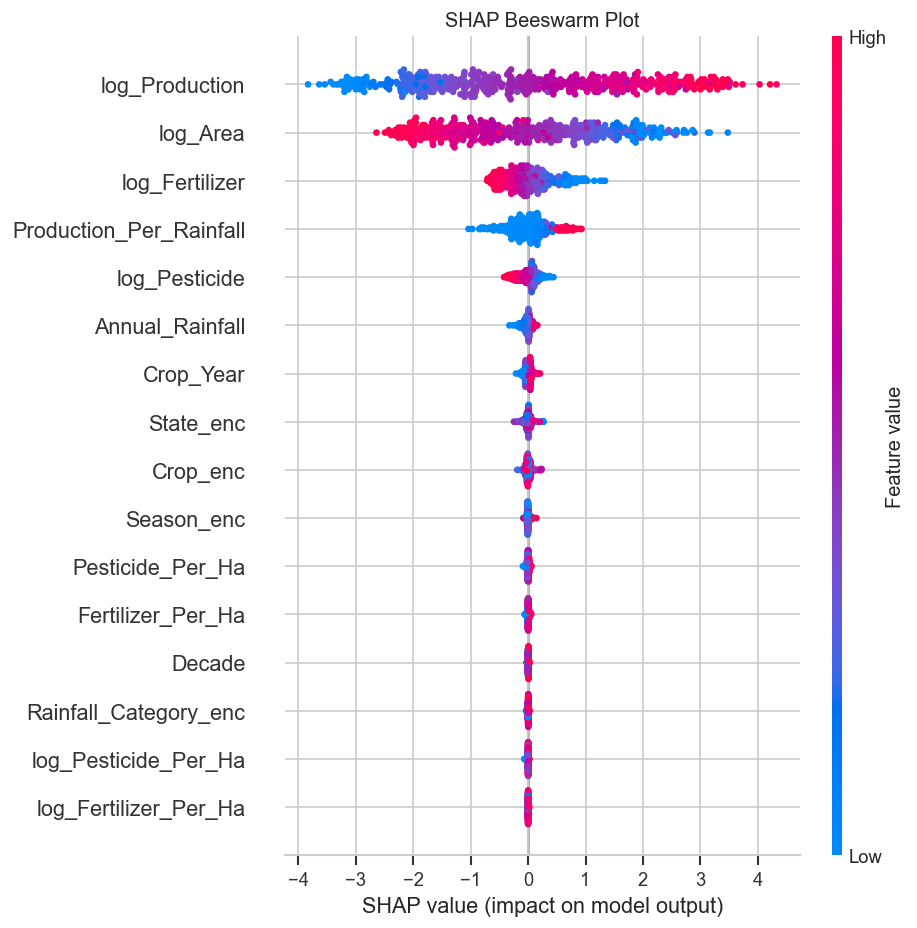

SHAP plots saved.


In [14]:
if HAS_SHAP:
    print('Computing SHAP values (may take a few minutes)...')
    # Use a sample for speed
    sample = X_test.sample(min(500, len(X_test)), random_state=42)

    explainer = shap.Explainer(model.predict, sample)
    shap_values = explainer(sample)

    # SHAP Summary Plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, sample, feature_names=sample.columns.tolist(),
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance (Mean |SHAP|)')
    plt.tight_layout()
    plt.savefig('shap_importance.png')
    plt.show()

    # SHAP Beeswarm
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, sample, feature_names=sample.columns.tolist(), show=False)
    plt.title('SHAP Beeswarm Plot')
    plt.tight_layout()
    plt.savefig('shap_beeswarm.png')
    plt.show()

    print('SHAP plots saved.')
else:
    print('SHAP not installed — skipping interpretability plots.')

## 8. SHAP Waterfall for a Single Prediction

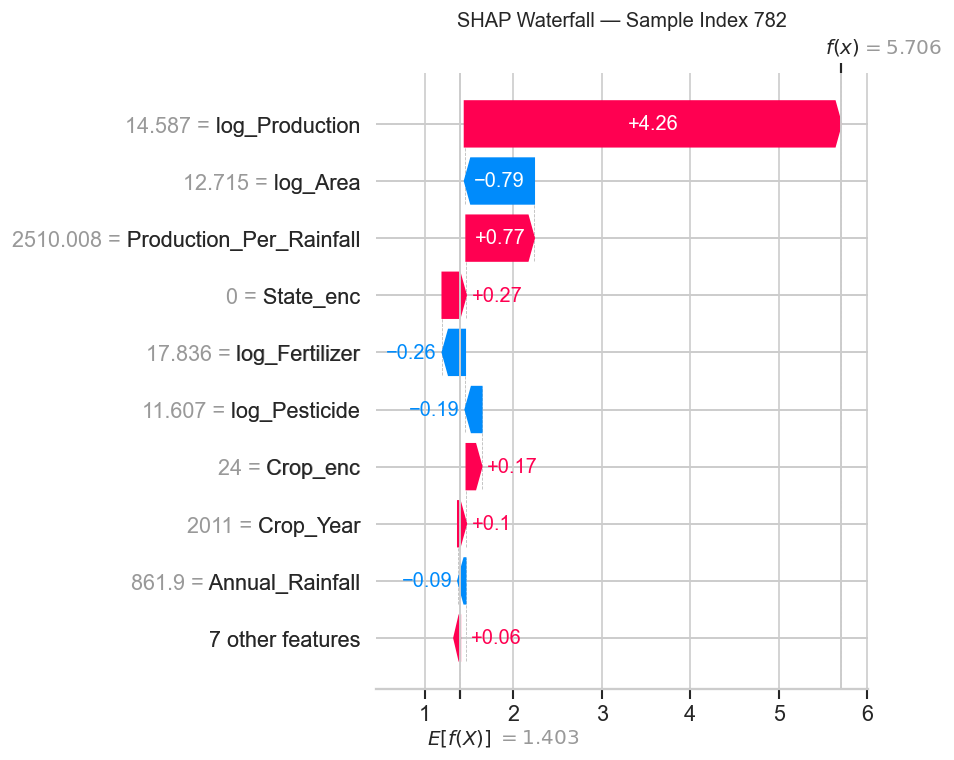

In [15]:
if HAS_SHAP:
    idx = 0  # Change to inspect any sample
    single = sample.iloc[[idx]]
    explanation = explainer(single)

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(explanation[0], show=False)
    plt.title(f'SHAP Waterfall — Sample Index {sample.index[idx]}')
    plt.tight_layout()
    plt.savefig('shap_waterfall.png')
    plt.show()
else:
    print('SHAP not installed')

## 9. Performance Summary Card

In [16]:
print('=' * 50)
print('  FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Model     : {summary["best_model_name"]}')
print(f'  Test R²   : {r2:.4f}')
print(f'  Test RMSE : {rmse:.4f}')
print(f'  Test MAE  : {mae:.4f}')
print(f'  Test MAPE : {mape:.2f}%')
print(f'  CV R²     : {summary["cv_r2_mean"]:.4f} ± {summary["cv_r2_std"]:.4f}')
print('=' * 50)

  FINAL MODEL PERFORMANCE SUMMARY
  Model     : XGB (Tuned)
  Test R²   : 0.9663
  Test RMSE : 0.2475
  Test MAE  : 0.1285
  Test MAPE : 371577449558525.06%
  CV R²     : 0.9615 ± 0.0047


---
✅ **Evaluation complete.** Proceed to `07_prediction_pipeline.ipynb`.